# Mod-Cog RNN training

In [1]:
import copy
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.animation import FuncAnimation

## Config

In [69]:
BANK_PATH = "modcog_bank.pt"
CKPT_PATH = "modcog_rnn.pt"
DEVICE = "cuda"
SEED = 0

N_HIDDEN = 256
TAU_MS = 200          # alpha = dt / tau
SIGMA_REC = 0.05      # recurrent noise (training only)
ACTIVATION = "relu"   # "relu" | "tanh" | "softplus"
L2_RATE = 1e-4        # penalty on hidden activity
L2_WEIGHT = 1e-4      # penalty on recurrent weights

BATCH = 256
LR = 1e-3
N_STEPS = 20_000
GRAD_CLIP = 1.0
RESP_WEIGHT = 5.0     # upweight response steps; fixation dominates the labels

VAL_FRAC = 0.1
EVAL_EVERY = 500
EVAL_BATCH = 2048
PROBE_PER_TASK = 32

# phase 1: emergence preview
SNAPSHOT_EVERY = 250      # state_dict copies are ~0.4 MB each
LOG_SNAPSHOTS = 12        # extra dense snapshots early, log-spaced over the first EVAL_EVERY steps
GIF_PATH = "emergence.gif"
GIF_FPS = 10

IGNORE_INDEX = -100
ACTIVATIONS = {"relu": F.relu, "tanh": torch.tanh, "softplus": F.softplus}

torch.manual_seed(SEED)

## Load bank onto the GPU

In [70]:
bank = torch.load(BANK_PATH, map_location=DEVICE)

obs = bank["obs"]              # (N, T, 33)
labels = bank["labels"]        # (N, T), padding = -100
lengths = bank["lengths"]      # (N,)
task_id = bank["task_id"]      # (N,)
family = bank["family"]        # (N,)
task_names = bank["task_names"]
family_names = bank["family_names"]

n_trials, t_max, ob_dim = obs.shape
n_tasks = len(task_names)
n_in = ob_dim + n_tasks
n_out = bank["n_ring"] + 1
alpha = bank["dt"] / TAU_MS
rule_eye = torch.eye(n_tasks, device=DEVICE)

print(f"{n_trials} trials, T={t_max}, n_in={n_in}, n_out={n_out}, alpha={alpha}")

20992 trials, T=67, n_in=115, n_out=17, alpha=0.25


## Train / val split and probe set

In [71]:
perm = torch.randperm(n_trials, device=DEVICE)
n_val = int(VAL_FRAC * n_trials)
val_idx = perm[:n_val]
train_idx = perm[n_val:]

# fixed probe set: first PROBE_PER_TASK val trials of each task (used for trajectory viz later)
val_tasks = task_id[val_idx]
order = torch.argsort(val_tasks, stable=True)
sorted_idx = val_idx[order]
sorted_tasks = val_tasks[order]
counts = torch.bincount(sorted_tasks, minlength=n_tasks)
starts = torch.cumsum(counts, 0) - counts
rank = torch.arange(len(sorted_idx), device=DEVICE) - starts[sorted_tasks]
probe_idx = sorted_idx[rank < PROBE_PER_TASK]

print(f"train {len(train_idx)}, val {len(val_idx)}, probe {len(probe_idx)}")

train 18893, val 2099, probe 2090


In [72]:
def make_batch(idx):
    """Gather trials and append the rule one-hot, all on GPU."""
    x = obs[idx]
    lens = lengths[idx]
    valid = torch.arange(x.shape[1], device=DEVICE)[None] < lens[:, None]
    rule = rule_eye[task_id[idx]][:, None] * valid[..., None]
    x = torch.cat([x * valid[..., None], rule], dim=-1)
    return x, labels[idx], lens, task_id[idx]

## Model

In [73]:
class LeakyRNN(nn.Module):
    def __init__(self, n_in, n_hidden, n_out, alpha, sigma_rec, activation):
        super().__init__()
        self.alpha = alpha
        self.noise_scale = math.sqrt(2 / alpha) * sigma_rec
        self.act = ACTIVATIONS[activation]
        self.n_hidden = n_hidden
        self.w_in = nn.Linear(n_in, n_hidden)
        self.w_rec = nn.Linear(n_hidden, n_hidden, bias=False)
        self.readout = nn.Linear(n_hidden, n_out)
        nn.init.orthogonal_(self.w_rec.weight, gain=0.3)

    def forward(self, x):
        """x: (B, T, n_in) -> logits (B, T, n_out), hidden (B, T, n_hidden)."""
        b, t, _ = x.shape
        h = x.new_zeros(b, self.n_hidden)
        hs = []
        for i in range(t):
            pre = self.w_in(x[:, i]) + self.w_rec(h)
            if self.training and self.noise_scale > 0:
                pre = pre + self.noise_scale * torch.randn_like(pre)
            h = (1 - self.alpha) * h + self.alpha * self.act(pre)
            hs.append(h)
        hidden = torch.stack(hs, dim=1)
        return self.readout(hidden), hidden


model = LeakyRNN(n_in, N_HIDDEN, n_out, alpha, SIGMA_REC, ACTIVATION).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)
print(sum(p.numel() for p in model.parameters()), "params")

99601 params


## Loss and evaluation

In [74]:
def compute_loss(logits, y, hidden, mask):
    ce = F.cross_entropy(
        logits.reshape(-1, n_out), y.reshape(-1),
        ignore_index=IGNORE_INDEX, reduction="none",
    ).view_as(y)
    w = torch.where(y > 0, RESP_WEIGHT, 1.0) * (y != IGNORE_INDEX)
    task_loss = (ce * w).sum() / w.sum()
    rate_loss = (hidden.pow(2) * mask[..., None]).sum() / (mask.sum() * hidden.shape[-1])
    weight_loss = model.w_rec.weight.pow(2).mean()
    return task_loss + L2_RATE * rate_loss + L2_WEIGHT * weight_loss


@torch.no_grad()
def evaluate(idx):
    """Per-task trial accuracy: fixation held on every fixation step AND last step correct."""
    model.eval()
    correct, tasks = [], []
    for chunk in idx.split(EVAL_BATCH):
        x, y, lens, task = make_batch(chunk)
        logits, _ = model(x)
        pred = logits.argmax(-1)
        fix_steps = y == 0
        fix_ok = ~((pred != 0) & fix_steps).any(dim=1)
        rows = torch.arange(len(chunk), device=DEVICE)
        last = lens - 1
        resp_ok = pred[rows, last] == y[rows, last]
        correct.append(fix_ok & resp_ok)
        tasks.append(task)
    correct = torch.cat(correct).float()
    tasks = torch.cat(tasks)
    model.train()
    hits = torch.bincount(tasks, weights=correct, minlength=n_tasks)
    totals = torch.bincount(tasks, minlength=n_tasks).clamp_min(1)
    return hits / totals

In [75]:
@torch.no_grad()
def probe_hidden(net=None):
    """Hidden states for the fixed probe set, noise off."""
    net = model if net is None else net
    was_training = net.training
    net.eval()
    x, _, lens, task = make_batch(probe_idx)
    _, hidden = net(x)
    net.train(was_training)
    return hidden, lens, task

In [76]:
def fit_direction_plane(unit, resp, step_angle, ridge=0.01):
    """Least squares map from normalized hidden state to (cos theta, sin theta)."""
    h = unit[resp]
    ang = step_angle[resp]
    target = torch.stack([torch.cos(ang), torch.sin(ang)], dim=1)
    a = h.T @ h + ridge * h.shape[0] * torch.eye(h.shape[1], device=h.device, dtype=h.dtype)
    w = torch.linalg.solve(a, h.T @ target)
    fit = h @ w
    r2 = 1 - ((target - fit) ** 2).sum() / ((target - target.mean(0)) ** 2).sum()
    return w, r2.item()

## Training loop

In [77]:
snap_at = set(range(SNAPSHOT_EVERY, N_STEPS + 1, SNAPSHOT_EVERY))
snap_at |= {int(round(s)) for s in np.unique(np.logspace(0, np.log10(EVAL_EVERY), LOG_SNAPSHOTS))}

loss_hist = torch.zeros(N_STEPS, device=DEVICE)   # stays on GPU; synced only at eval
acc_hist = []
eval_steps = []
snapshots = [(0, copy.deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()}))]

model.train()
t0 = time.perf_counter()
for step in range(N_STEPS):
    batch_idx = train_idx[torch.randint(len(train_idx), (BATCH,), device=DEVICE)]
    x, y, lens, _ = make_batch(batch_idx)
    mask = torch.arange(x.shape[1], device=DEVICE)[None] < lens[:, None]

    logits, hidden = model(x)
    loss = compute_loss(logits, y, hidden, mask)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    opt.step()
    loss_hist[step] = loss.detach()

    if (step + 1) in snap_at:
        snapshots.append((step + 1, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}))

    if (step + 1) % EVAL_EVERY == 0:
        per_task = evaluate(val_idx)
        acc_hist.append(per_task)
        eval_steps.append(step + 1)
        window_loss = loss_hist[step + 1 - EVAL_EVERY : step + 1].mean().item()
        print(
            f"step {step + 1:>6} | loss {window_loss:.4f} | "
            f"mean acc {per_task.mean().item():.3f} | min acc {per_task.min().item():.3f} | "
            f"{time.perf_counter() - t0:.0f}s"
        )

print(f"{len(snapshots)} snapshots, "
      f"{sum(v.numel() * 4 for _, sd in snapshots for v in sd.values()) / 1e6:.0f} MB")

step    500 | loss 2.0198 | mean acc 0.079 | min acc 0.000 | 7s
step   1000 | loss 1.7624 | mean acc 0.147 | min acc 0.000 | 14s
step   1500 | loss 1.4092 | mean acc 0.271 | min acc 0.000 | 21s
step   2000 | loss 1.0904 | mean acc 0.330 | min acc 0.000 | 28s
step   2500 | loss 0.9305 | mean acc 0.384 | min acc 0.000 | 35s
step   3000 | loss 0.8325 | mean acc 0.446 | min acc 0.040 | 41s
step   3500 | loss 0.7736 | mean acc 0.451 | min acc 0.040 | 48s
step   4000 | loss 0.7057 | mean acc 0.529 | min acc 0.000 | 55s
step   4500 | loss 0.6549 | mean acc 0.493 | min acc 0.000 | 62s
step   5000 | loss 0.6064 | mean acc 0.506 | min acc 0.080 | 68s
step   5500 | loss 0.5580 | mean acc 0.511 | min acc 0.040 | 75s
step   6000 | loss 0.5230 | mean acc 0.638 | min acc 0.000 | 82s
step   6500 | loss 0.4911 | mean acc 0.600 | min acc 0.000 | 89s
step   7000 | loss 0.4553 | mean acc 0.629 | min acc 0.000 | 95s
step   7500 | loss 0.4227 | mean acc 0.575 | min acc 0.000 | 102s
step   8000 | loss 0.4030

## Results

In [78]:
extension = bank["extension"]
extension_names = bank["extension_names"]
direction = bank["direction"]
color_angle = bank["color_angle"]

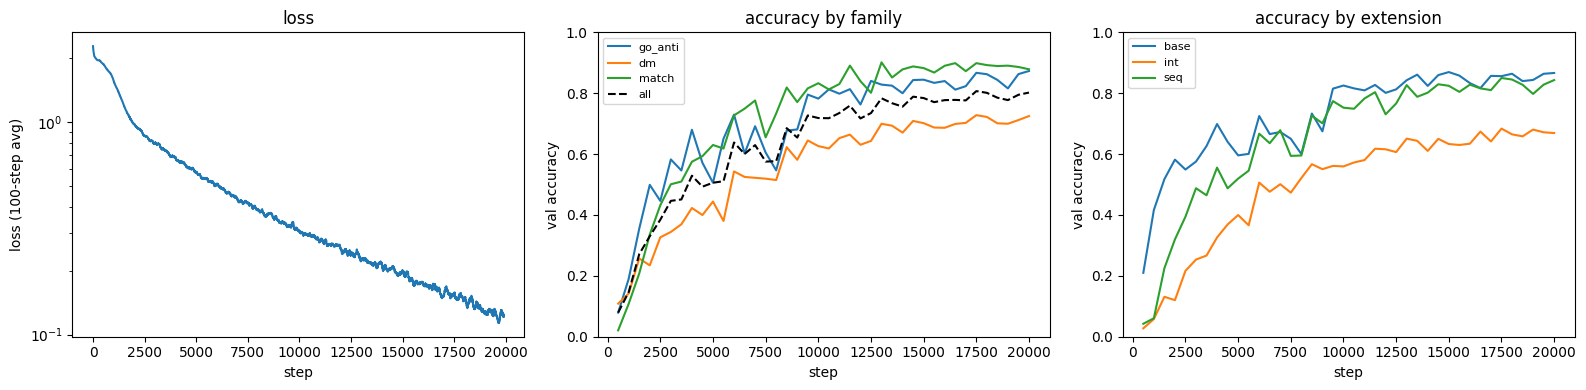

In [79]:
loss_np = loss_hist.cpu().numpy()
acc_np = torch.stack(acc_hist).cpu().numpy()

task_family = torch.stack([family[task_id == k][0] for k in range(n_tasks)]).cpu().numpy()
task_ext = torch.stack([extension[task_id == k][0] for k in range(n_tasks)]).cpu().numpy()
final = acc_np[-1]

w = min(100, max(1, len(loss_np) // 20))
kernel = np.ones(w) / w
smooth = lambda y: np.convolve(y, kernel, mode="valid")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(smooth(loss_np))
axes[0].set_yscale("log")
axes[0].set(xlabel="step", ylabel=f"loss ({w}-step avg)", title="loss")

for f, name in enumerate(family_names):
    axes[1].plot(eval_steps, acc_np[:, task_family == f].mean(axis=1), label=name)
axes[1].plot(eval_steps, acc_np.mean(axis=1), "k--", label="all")
axes[1].set(xlabel="step", ylabel="val accuracy", ylim=(0, 1), title="accuracy by family")
axes[1].legend(fontsize=8)

for e, name in enumerate(extension_names):
    axes[2].plot(eval_steps, acc_np[:, task_ext == e].mean(axis=1), label=name)
axes[2].set(xlabel="step", ylabel="val accuracy", ylim=(0, 1), title="accuracy by extension")
axes[2].legend(fontsize=8)
plt.tight_layout()

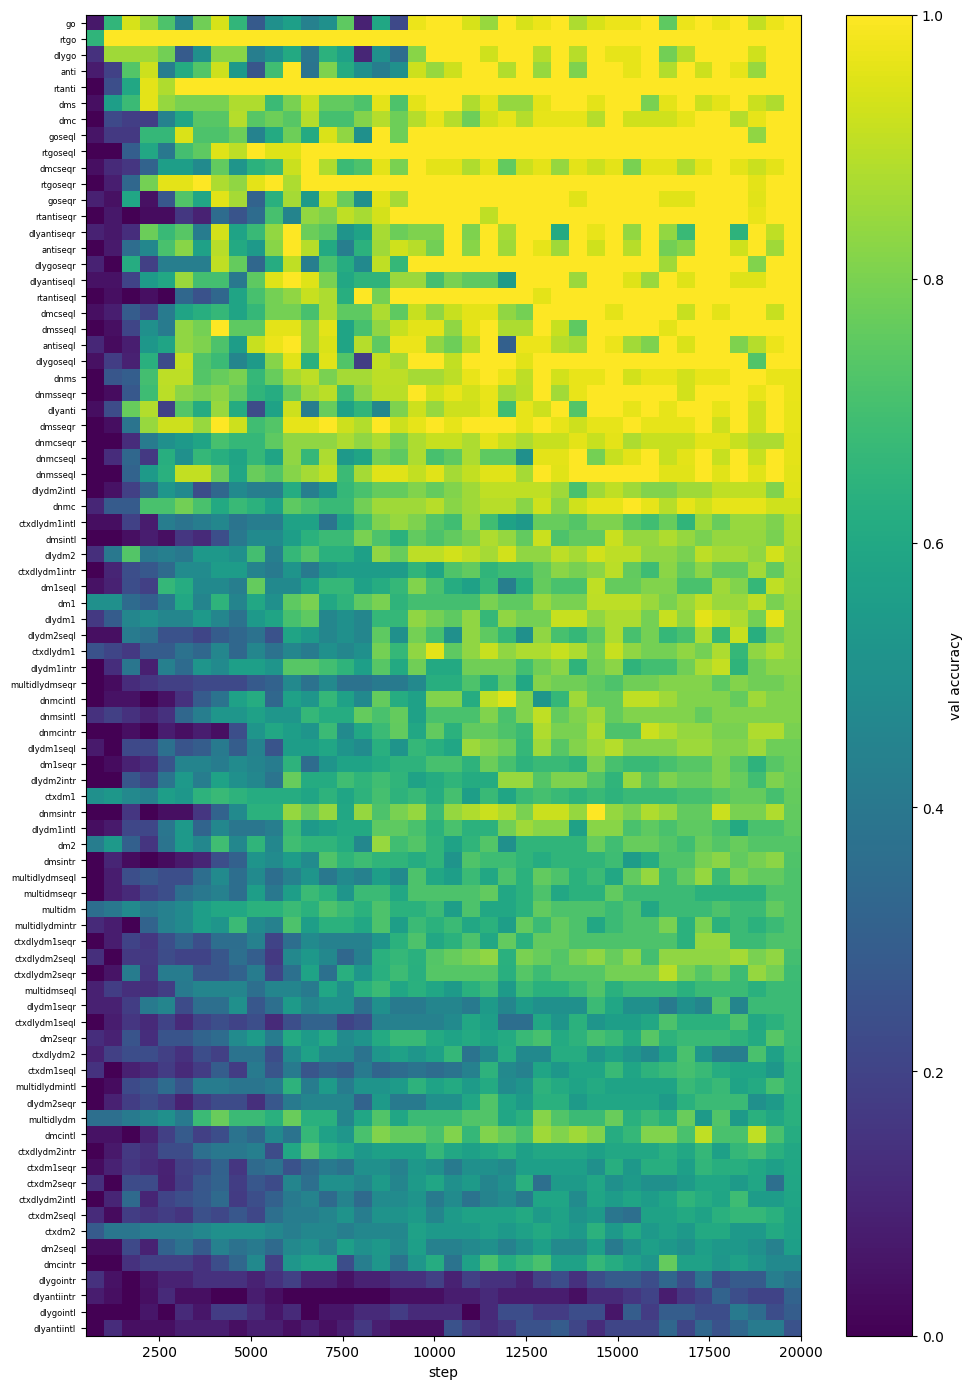

worst tasks: [('ctxdm2seqr', 0.591), ('ctxdlydm2intl', 0.586), ('ctxdm2seql', 0.576), ('ctxdm2', 0.571), ('dm2seql', 0.562), ('dmcintr', 0.476), ('dlygointr', 0.381), ('dlyantiintr', 0.32), ('dlygointl', 0.294), ('dlyantiintl', 0.25)]
mean acc 0.802 


In [80]:
order = np.argsort(-final)

fig, ax = plt.subplots(figsize=(10, 14))
im = ax.imshow(acc_np[:, order].T, aspect="auto", vmin=0, vmax=1, cmap="viridis",
               extent=[eval_steps[0], eval_steps[-1], n_tasks - 0.5, -0.5])
ax.set_yticks(range(n_tasks))
ax.set_yticklabels([task_names[k] for k in order], fontsize=6)
ax.set_xlabel("step")
fig.colorbar(im, ax=ax, label="val accuracy")
plt.tight_layout()
plt.savefig("bah.png")
plt.show()

print("worst tasks:", [(task_names[k], round(float(final[k]), 3)) for k in order[-10:]])
print(f"mean acc {final.mean():.3f} ")

# PCA

In [81]:
hidden, lens, task = probe_hidden()
valid = torch.arange(t_max, device=DEVICE)[None] < lens[:, None]
unit = hidden / hidden.norm(dim=-1, keepdim=True).clamp_min(1e-8)

lab = labels[probe_idx]
resp = lab > 0
step_angle = (lab - 1).float() * 2 * torch.pi / bank["n_ring"]

# fit the direction plane on response steps: h -> (cos theta, sin theta)
h_resp = unit[resp]
ang_resp = step_angle[resp]
target = torch.stack([torch.cos(ang_resp), torch.sin(ang_resp)], dim=1)
w = torch.linalg.lstsq(h_resp, target).solution          # (n_hidden, 2)
q, _ = torch.linalg.qr(w)                                # orthonormal plane

fit = h_resp @ w
r2 = 1 - ((target - fit) ** 2).sum() / ((target - target.mean(0)) ** 2).sum()
proj = (unit @ q).cpu().numpy()                          # (P, T, 2)

print(f"R^2 {r2.item():.3f}")
for e, name in enumerate(extension_names):
    m = resp & (extension[probe_idx] == e)[:, None]
    f = unit[m] @ w
    t = torch.stack([torch.cos(step_angle[m]), torch.sin(step_angle[m])], dim=1)
    print(f"  {name}: R^2 {1 - ((t - f) ** 2).sum() / ((t - t.mean(0)) ** 2).sum():.3f}")

R^2 0.813
  base: R^2 0.890
  int: R^2 0.700
  seq: R^2 0.821


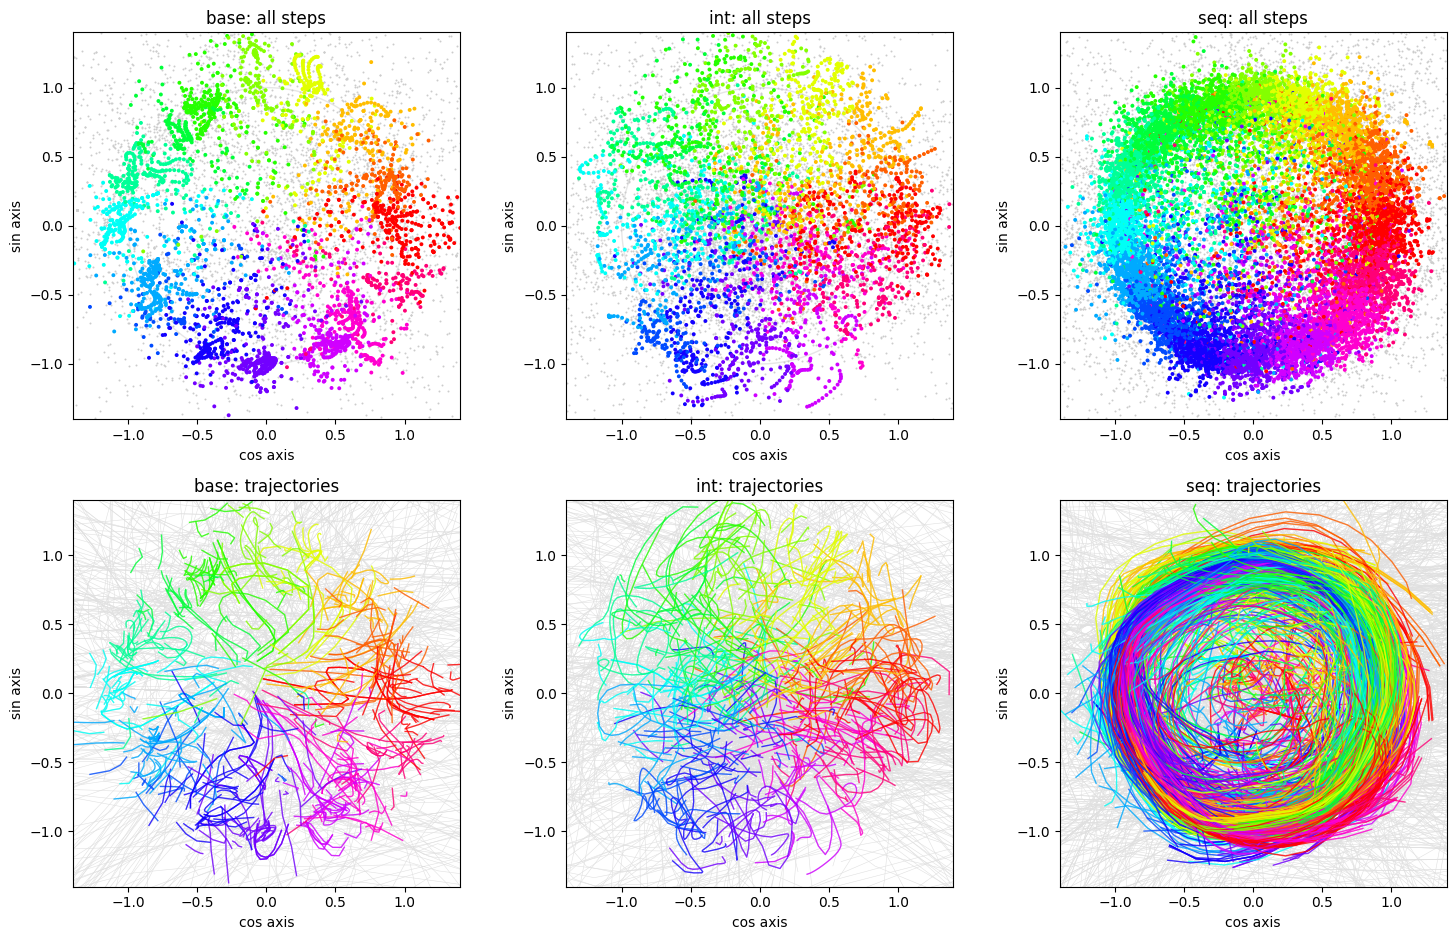

In [82]:
decoded = (unit @ w).cpu().numpy()          # (P, T, 2) — predicted (cos, sin)

step_colors = plt.cm.hsv((step_angle / (2 * torch.pi)).clamp(0, 1).cpu().numpy())
probe_ext = extension[probe_idx].cpu().numpy()
lens_np = lens.cpu().numpy()
resp_np = resp.cpu().numpy()
valid_np = valid.cpu().numpy()

circle = np.exp(1j * np.linspace(0, 2 * np.pi, 200))
lim = 1.4

fig, axes = plt.subplots(2, len(extension_names), figsize=(5 * len(extension_names), 9.5))

for e, name in enumerate(extension_names):
    sel = np.flatnonzero(probe_ext == e)

    for row in (0, 1):
        ax = axes[row, e]
        ax.plot(circle.real, circle.imag, color="0.9", lw=1, zorder=0)
        ax.set(xlabel="cos axis", ylabel="sin axis", xlim=(-lim, lim), ylim=(-lim, lim))
        ax.set_aspect("equal")

    ax = axes[0, e]
    for p in sel:
        m = valid_np[p] & ~resp_np[p]
        ax.scatter(decoded[p, m, 0], decoded[p, m, 1], c="0.8", s=2, linewidths=0)
    for p in sel:
        m = resp_np[p]
        ax.scatter(decoded[p, m, 0], decoded[p, m, 1], c=step_colors[p][m], s=8, linewidths=0)
    ax.set_title(f"{name}: all steps")

    ax = axes[1, e]
    for p in sel:
        n = lens_np[p]
        ax.plot(decoded[p, :n, 0], decoded[p, :n, 1], color="0.88", lw=0.4, zorder=0)
        m = resp_np[p]
        if m.any():
            ax.plot(decoded[p, m, 0], decoded[p, m, 1],
                    color=step_colors[p][m][0], lw=1.0, alpha=0.8)
    ax.set_title(f"{name}: trajectories")
plt.tight_layout()

# Phase 1: does the ring emerge gradually or snap into place?

Replay every snapshot through the fixed probe set, project onto the direction plane, and animate.
Two versions: a **fixed** plane fit on the final model (structure converges onto it) and a **refit**
plane fit per snapshot (what the network encodes at that moment).

In [83]:
def circular_corr(a, b):
    """Correlation between two angle sets; bounded in [-1, 1], scale-free."""
    am = torch.atan2(torch.sin(a).mean(), torch.cos(a).mean())
    bm = torch.atan2(torch.sin(b).mean(), torch.cos(b).mean())
    sa, sb = torch.sin(a - am), torch.sin(b - bm)
    return (sa * sb).sum() / torch.sqrt((sa ** 2).sum() * (sb ** 2).sum())

In [84]:
lab = labels[probe_idx]
resp = lab > 0
step_angle = (lab - 1).float() * 2 * torch.pi / bank["n_ring"]

hidden, lens, task = probe_hidden()
unit = hidden / hidden.norm(dim=-1, keepdim=True).clamp_min(1e-8)
w_final, r2_final = fit_direction_plane(unit, resp, step_angle)
print(f"final-model plane: R^2 {r2_final:.3f}")

scratch = LeakyRNN(n_in, N_HIDDEN, n_out, alpha, SIGMA_REC, ACTIVATION).to(DEVICE)
scratch.eval()

snap_steps = []
circcorr_hist = []
dec_fixed, dec_refit, r2_hist, radius_hist = [], [], [], []

for step, state in snapshots:
    scratch.load_state_dict({k: v.to(DEVICE) for k, v in state.items()})
    h, _, _ = probe_hidden(scratch)
    u = h / h.norm(dim=-1, keepdim=True).clamp_min(1e-8)

    w_now, r2_now = fit_direction_plane(u, resp, step_angle)
    d_fixed = u @ w_final
    dec_angle = torch.atan2(d_fixed[..., 1], d_fixed[..., 0])[resp]
    circcorr_hist.append(circular_corr(dec_angle, step_angle[resp]).item())
    d_refit = u @ w_now

    snap_steps.append(step)
    dec_fixed.append(d_fixed.cpu().numpy())
    dec_refit.append(d_refit.cpu().numpy())
    r2_hist.append(r2_now)
    radius_hist.append(d_fixed[resp].norm(dim=-1).mean().item())

dec_fixed = np.stack(dec_fixed)     # (n_snap, P, T, 2)
dec_refit = np.stack(dec_refit)
snap_steps = np.array(snap_steps)
r2_hist = np.array(r2_hist)
radius_hist = np.array(radius_hist)
print(dec_fixed.shape)

final-model plane: R^2 0.723
(92, 2090, 67, 2)


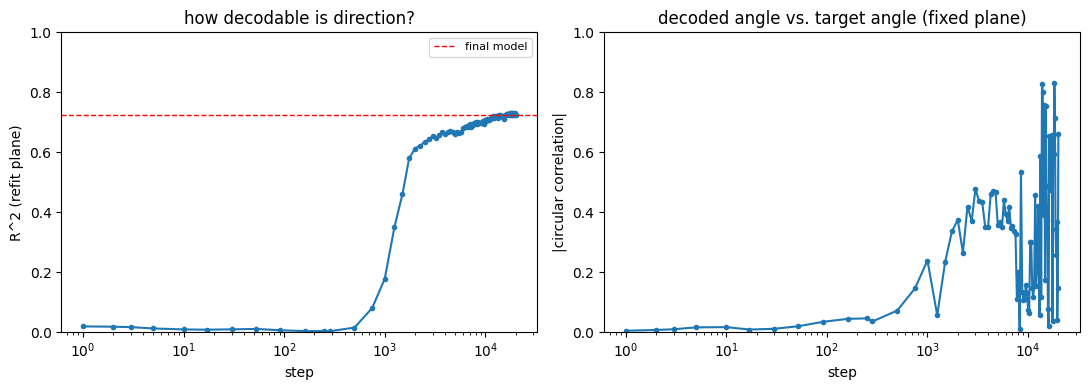

In [85]:
circcorr_hist = np.array(circcorr_hist)
keep = snap_steps > 0          # step 0 is untrained; its lstsq fit is degenerate

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(snap_steps[keep], r2_hist[keep], marker="o", ms=3)
axes[0].axhline(r2_final, color="r", ls="--", lw=1, label="final model")
axes[0].set(xlabel="step", ylabel="R^2 (refit plane)", ylim=(0, 1),
            title="how decodable is direction?")
axes[0].set_xscale("log")
axes[0].legend(fontsize=8)

axes[1].plot(snap_steps[keep], np.abs(circcorr_hist)[keep], marker="o", ms=3)
axes[1].set(xlabel="step", ylabel="|circular correlation|", ylim=(0, 1), 
            title="decoded angle vs. target angle (fixed plane)")
axes[1].set_xscale("log")
plt.tight_layout()

In [29]:
print(len(circcorr_hist), len(snap_steps))
print(np.round(circcorr_hist, 3))

92 92
[-0.013 -0.015 -0.013 -0.01  -0.012  0.014 -0.019  0.013  0.012  0.016
  0.004  0.014  0.022  0.037 -0.023 -0.24  -0.305 -0.349 -0.506 -0.554
 -0.554 -0.576 -0.578 -0.595 -0.591 -0.575 -0.643 -0.643 -0.602 -0.669
 -0.684 -0.674 -0.687 -0.68  -0.676 -0.721 -0.725 -0.748 -0.731 -0.782
 -0.755 -0.76  -0.773 -0.774 -0.74  -0.78  -0.752 -0.754 -0.765 -0.768
 -0.781 -0.789 -0.783 -0.785 -0.787 -0.778 -0.779 -0.795 -0.798 -0.759
 -0.794 -0.729 -0.731 -0.7   -0.698 -0.563 -0.703 -0.637 -0.592 -0.759
 -0.683 -0.238 -0.753 -0.726 -0.506 -0.459  0.004 -0.365 -0.647 -0.691
 -0.506 -0.483 -0.314 -0.399 -0.632 -0.526 -0.265 -0.351 -0.289 -0.063
  0.422  0.896]


In [18]:
probe_ext = extension[probe_idx].cpu().numpy()
resp_np = resp.cpu().numpy()
lens_np = lens.cpu().numpy()
step_colors = plt.cm.hsv((step_angle / (2 * torch.pi)).clamp(0, 1).cpu().numpy())
circle = np.exp(1j * np.linspace(0, 2 * np.pi, 200))


def emergence_animation(dec, title, path, lim=1.4):
    """Animate response-step positions across snapshots, one panel per extension."""
    fig, axes = plt.subplots(1, len(extension_names), figsize=(5 * len(extension_names), 5.4))
    artists = []
    for e, name in enumerate(extension_names):
        ax = axes[e]
        ax.plot(circle.real, circle.imag, color="0.9", lw=1, zorder=0)
        ax.set(xlabel="cos axis", ylabel="sin axis", title=name,
               xlim=(-lim, lim), ylim=(-lim, lim))
        ax.set_aspect("equal")
        sel = np.flatnonzero(probe_ext == e)
        mask = resp_np[sel]
        sc = ax.scatter(np.zeros(mask.sum()), np.zeros(mask.sum()), s=6, linewidths=0)
        sc.set_color(step_colors[sel][mask])
        artists.append((sc, sel, mask))
    text = fig.suptitle("")

    def update(i):
        for sc, sel, mask in artists:
            sc.set_offsets(dec[i][sel][mask])
        text.set_text(f"{title} — step {snap_steps[i]}")
        return [a[0] for a in artists]

    anim = FuncAnimation(fig, update, frames=len(dec), interval=1000 // GIF_FPS, blit=False)
    anim.save(path, writer="pillow", fps=GIF_FPS)
    plt.close(fig)
    print("saved", path)
    return anim


emergence_animation(dec_fixed, "fixed plane", GIF_PATH)
emergence_animation(dec_refit, "refit plane", GIF_PATH.replace(".gif", "_refit.gif"))

saved emergence.gif
saved emergence_refit.gif


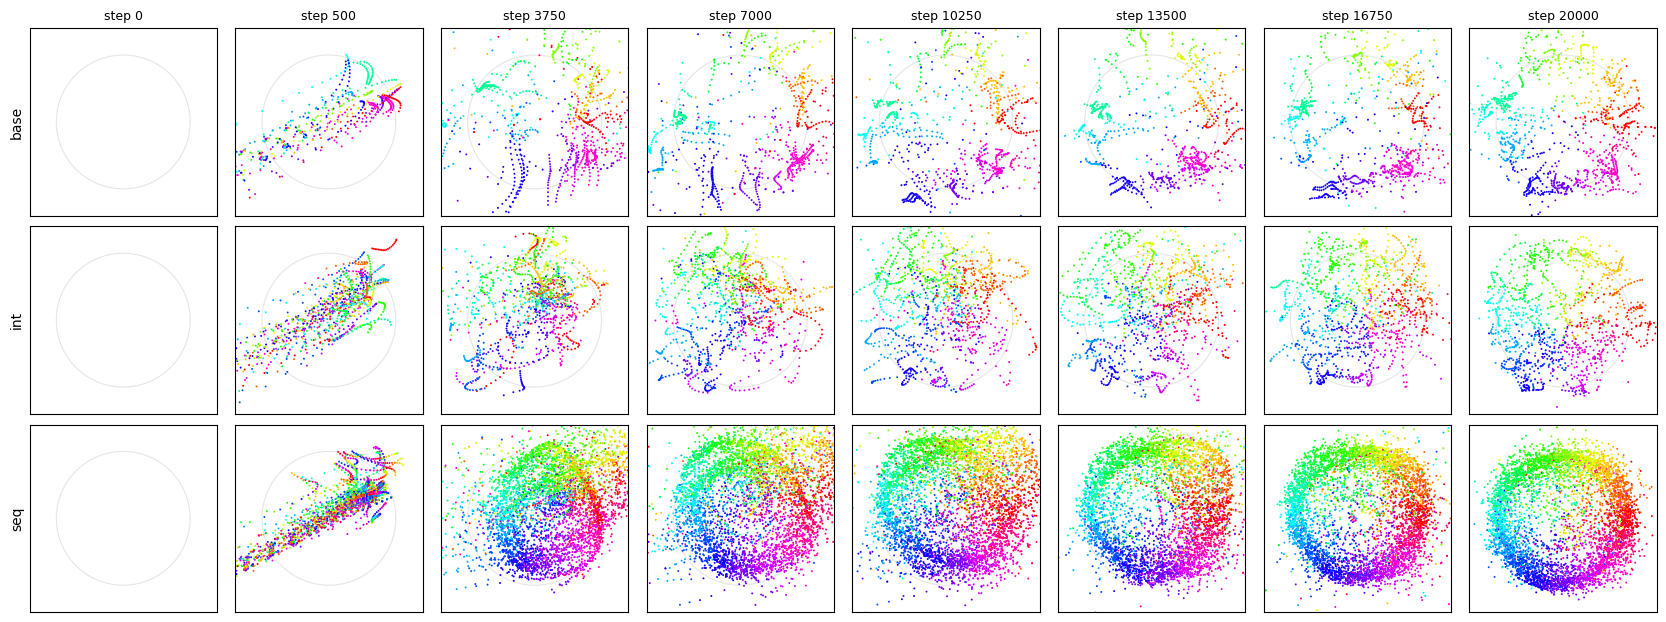

In [19]:
picks = np.unique(np.linspace(0, len(snap_steps) - 1, 8).astype(int))
lim = 1.4

fig, axes = plt.subplots(len(extension_names), len(picks),
                         figsize=(2.1 * len(picks), 2.1 * len(extension_names)))
for col, i in enumerate(picks):
    for e, name in enumerate(extension_names):
        ax = axes[e, col]
        sel = np.flatnonzero(probe_ext == e)
        mask = resp_np[sel]
        xy = dec_fixed[i][sel][mask]
        ax.scatter(xy[:, 0], xy[:, 1], c=step_colors[sel][mask], s=2, linewidths=0)
        ax.plot(circle.real, circle.imag, color="0.9", lw=0.8, zorder=0)
        ax.set(xlim=(-lim, lim), ylim=(-lim, lim), xticks=[], yticks=[])
        ax.set_aspect("equal")
        if col == 0:
            ax.set_ylabel(name)
        if e == 0:
            ax.set_title(f"step {snap_steps[i]}", fontsize=9)
plt.tight_layout()
#plt.savefig("emergence_grid.png", dpi=200, bbox_inches="tight")

In [86]:
def plane_alignment(w_a, w_b):
    """Mean cosine of principal angles between two 2D subspaces; 1 = identical, 0 = orthogonal."""
    q_a, _ = torch.linalg.qr(w_a)
    q_b, _ = torch.linalg.qr(w_b)
    return torch.linalg.svdvals(q_a.T @ q_b).mean().item()


# split the probe set in half by trial, keeping tasks balanced
half_a = torch.zeros(len(probe_idx), dtype=torch.bool, device=DEVICE)
half_a[::2] = True
half_b = ~half_a

split_align, consec_align, align_to_final = [], [], []
w_prev = None

for step, state in snapshots:
    scratch.load_state_dict({k: v.to(DEVICE) for k, v in state.items()})
    h, _, _ = probe_hidden(scratch)
    u = h / h.norm(dim=-1, keepdim=True).clamp_min(1e-8)

    w_all, _ = fit_direction_plane(u, resp, step_angle)
    w_a, _ = fit_direction_plane(u[half_a], resp[half_a], step_angle[half_a])
    w_b, _ = fit_direction_plane(u[half_b], resp[half_b], step_angle[half_b])

    split_align.append(plane_alignment(w_a, w_b))
    align_to_final.append(plane_alignment(w_all, w_final))
    consec_align.append(np.nan if w_prev is None else plane_alignment(w_prev, w_all))
    w_prev = w_all

split_align = np.array(split_align)
consec_align = np.array(consec_align)
align_to_final = np.array(align_to_final)

late: split 0.982 | consecutive 0.997 | vs final 0.990


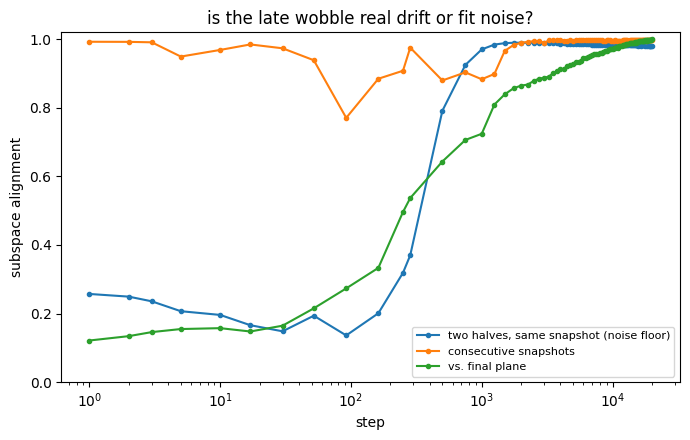

In [87]:
keep = snap_steps > 0

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(snap_steps[keep], split_align[keep], marker="o", ms=3, label="two halves, same snapshot (noise floor)")
ax.plot(snap_steps[keep], consec_align[keep], marker="o", ms=3, label="consecutive snapshots")
ax.plot(snap_steps[keep], align_to_final[keep], marker="o", ms=3, label="vs. final plane")
ax.set(xlabel="step", ylabel="subspace alignment", ylim=(0, 1.02),
       title="is the late wobble real drift or fit noise?")
ax.set_xscale("log")
ax.legend(fontsize=8)
plt.tight_layout()

late = snap_steps > 10_000
print(f"late: split {np.nanmean(split_align[late]):.3f} | "
      f"consecutive {np.nanmean(consec_align[late]):.3f} | "
      f"vs final {np.nanmean(align_to_final[late]):.3f}")

In [89]:
RIDGE = 0.01

snap_steps, dec_refit, r2_hist = [], [], []

for step, state in snapshots:
    scratch.load_state_dict({k: v.to(DEVICE) for k, v in state.items()})
    h, _, _ = probe_hidden(scratch)
    u = h / h.norm(dim=-1, keepdim=True).clamp_min(1e-8)
    w_now, r2_now = fit_direction_plane(u, resp, step_angle, ridge=RIDGE)

    snap_steps.append(step)
    dec_refit.append((u @ w_now).cpu().numpy())
    r2_hist.append(r2_now)

snap_steps = np.array(snap_steps)
dec_refit = np.stack(dec_refit)
r2_hist = np.array(r2_hist)
print(dec_refit.shape, f"max |decoded| {np.abs(dec_refit).max():.1f}")

(92, 2090, 67, 2) max |decoded| 1.3


In [91]:
probe_ext = extension[probe_idx].cpu().numpy()
resp_np = resp.cpu().numpy()
step_colors = plt.cm.hsv((step_angle / (2 * torch.pi)).clamp(0, 1).cpu().numpy())
circle = np.exp(1j * np.linspace(0, 2 * np.pi, 200))

LIM = 1.4

fig, axes = plt.subplots(1, len(extension_names), figsize=(5 * len(extension_names), 5.6))
artists = []
for e, name in enumerate(extension_names):
    ax = axes[e]
    ax.plot(circle.real, circle.imag, color="0.9", lw=1, zorder=0)
    ax.set(xlabel="cos axis", ylabel="sin axis", title=name, xlim=(-LIM, LIM), ylim=(-LIM, LIM))
    ax.set_aspect("equal")
    sel = np.flatnonzero(probe_ext == e)
    mask = resp_np[sel]
    sc = ax.scatter(np.zeros(mask.sum()), np.zeros(mask.sum()), s=4, linewidths=0, alpha=0.7)
    sc.set_color(step_colors[sel][mask])
    artists.append((sc, sel, mask))
title = fig.suptitle("", fontsize=13)


def update(i):
    for sc, sel, mask in artists:
        sc.set_offsets(np.clip(dec_refit[i][sel][mask], -LIM, LIM))
    title.set_text(f"step {snap_steps[i]:,}    R² {r2_hist[i]:.2f}")
    return [a[0] for a in artists]


frames = list(range(len(dec_refit))) + [len(dec_refit) - 1] * (GIF_FPS * 2)
anim = FuncAnimation(fig, update, frames=frames, interval=1000 // GIF_FPS)
anim.save("emergence_refit.gif", writer="pillow", fps=GIF_FPS)
plt.close(fig)
print("saved emergence_refit.gif")

saved emergence_refit.gif


## Save

In [15]:
# torch.save(
#     {
#         "model": model.state_dict(),
#         "config": {
#             "n_in": n_in, "n_hidden": N_HIDDEN, "n_out": n_out, "alpha": alpha,
#             "sigma_rec": SIGMA_REC, "activation": ACTIVATION,
#         },
#         "val_idx": val_idx.cpu(),
#         "probe_idx": probe_idx.cpu(),
#         "loss_hist": loss_hist.cpu(),
#         "acc_hist": torch.stack(acc_hist).cpu(),
#         "eval_steps": eval_steps,
#         "w_plane": w_final.cpu(),
#         "snapshots": snapshots,
#         "snap_steps": snap_steps,
#     },
#     CKPT_PATH,
# )
# print("saved", CKPT_PATH)

saved modcog_rnn.pt
